<a href="https://colab.research.google.com/github/sidbhaumik/sidb_datascience_projects.github.io/blob/gh-pages/Scalable_Anomaly_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚨 Scalable Anomaly Detection: Isolation Forest Vs Lof

This notebook demonstrates how to:
- Simulate realistic time-series metrics (CPU, memory, disk)
- Inject realistic anomalies into the data
- Detect anomalies using Isolation Forest & Lof
- Visualize the results

You'll also learn how to extend this approach to real-time detection using Kafka and Spark.


👉 **Note**: This notebook requires `pandas`, `numpy`, `scikit-learn`, and `matplotlib`. You can install them using pip if running locally.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
import logging
import seaborn as sns

# Logging setup
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
np.random.seed(42)

In [2]:
# Step 1: Generate Synthetic data with One million rows
def generate_realistic_data(n_samples=1_000_000):
    timestamps = pd.date_range(start='2025-01-01', periods=n_samples, freq='min')
    base_cpu = np.random.normal(50, 10, n_samples)
    base_memory = np.random.normal(60, 15, n_samples)
    base_latency = np.random.normal(100, 20, n_samples)
    base_disk = np.random.normal(75, 10, n_samples)

    # Introduce correlated spikes to simulate real anomalies
    for i in range(0, n_samples, 50000):
        base_memory[i:i+1000] += 30  # memory spike
        base_cpu[i:i+1000] += 20
        base_disk[i:i+1000] += 15
        base_latency[i:i+1000] += 50

   # Error Rate
    error_rate = np.random.choice([0, 1], size=n_samples, p=[0.98, 0.02])

    # Returns a pandas DataFrame with timestamps and other metrics
    df = pd.DataFrame({
        'timestamp': timestamps,
        'cpu_usage': base_cpu,
        'memory_usage': base_memory,
        'network_latency': base_latency,
        'disk_io': base_disk,
        'error_rate': error_rate
    })
    return df

In [3]:
# Calls the function to generate the synthetic dataset
df = generate_realistic_data()

# Information logging
logging.info(f"Generated dataset with shape: {df.shape}")
df.head()

,timestamp,cpu_usage,memory_usage,network_latency,disk_io,error_rate
0,2025-01-01 00:00:00,74.967142,92.537578,171.294448,78.928398,0
1,2025-01-01 00:01:00,68.617357,88.177423,140.065736,72.306378,0
2,2025-01-01 00:02:00,76.476885,107.349379,152.585204,86.621920,0
3,2025-01-01 00:03:00,85.230299,93.001287,120.406133,95.023779,0
4,2025-01-01 00:04:00,67.658466,102.969160,143.803054,94.435034,0


In [4]:
#Step 2:  function to implement anomaly detection using the Isolation Forest algorithm
def detect_anomalies(df):
    model = IsolationForest(n_estimators=100, contamination=0.02, random_state=42, n_jobs=-1)
    numeric_cols = df.select_dtypes(include=[float, int]).drop(columns=['error_rate'])
    df['anomaly'] = model.fit_predict(numeric_cols)
    return df

In [5]:
# This code applies the anomaly detection function and then analyzes the results
df = detect_anomalies(df)
logging.info(df['anomaly'].value_counts())
df['anomaly'].value_counts(normalize=True)

,proportion
anomaly,
1,0.98
-1,0.02


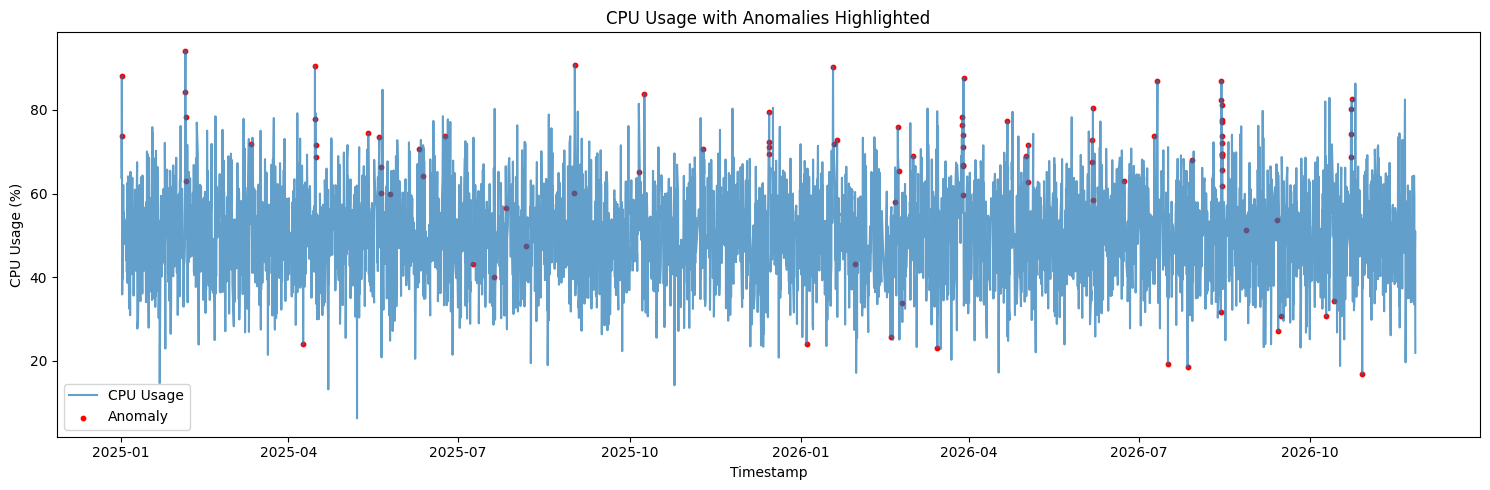

In [6]:
# Step 3: Visualize system metrics (sampled for performance)

sample_df = df.sample(5000).sort_values('timestamp')

# 3a: A time series showing CPU usage fluctuations with red dots marking where the Isolation Forest detected anomalies.
plt.figure(figsize=(15, 5))
plt.plot(sample_df['timestamp'], sample_df['cpu_usage'], label='CPU Usage', alpha=0.7)
plt.scatter(sample_df['timestamp'][sample_df['anomaly'] == -1],
            sample_df['cpu_usage'][sample_df['anomaly'] == -1],
            color='red', label='Anomaly', s=10)
plt.legend()
plt.title('CPU Usage with Anomalies Highlighted')
plt.xlabel('Timestamp')
plt.ylabel('CPU Usage (%)')
plt.tight_layout()
plt.show()

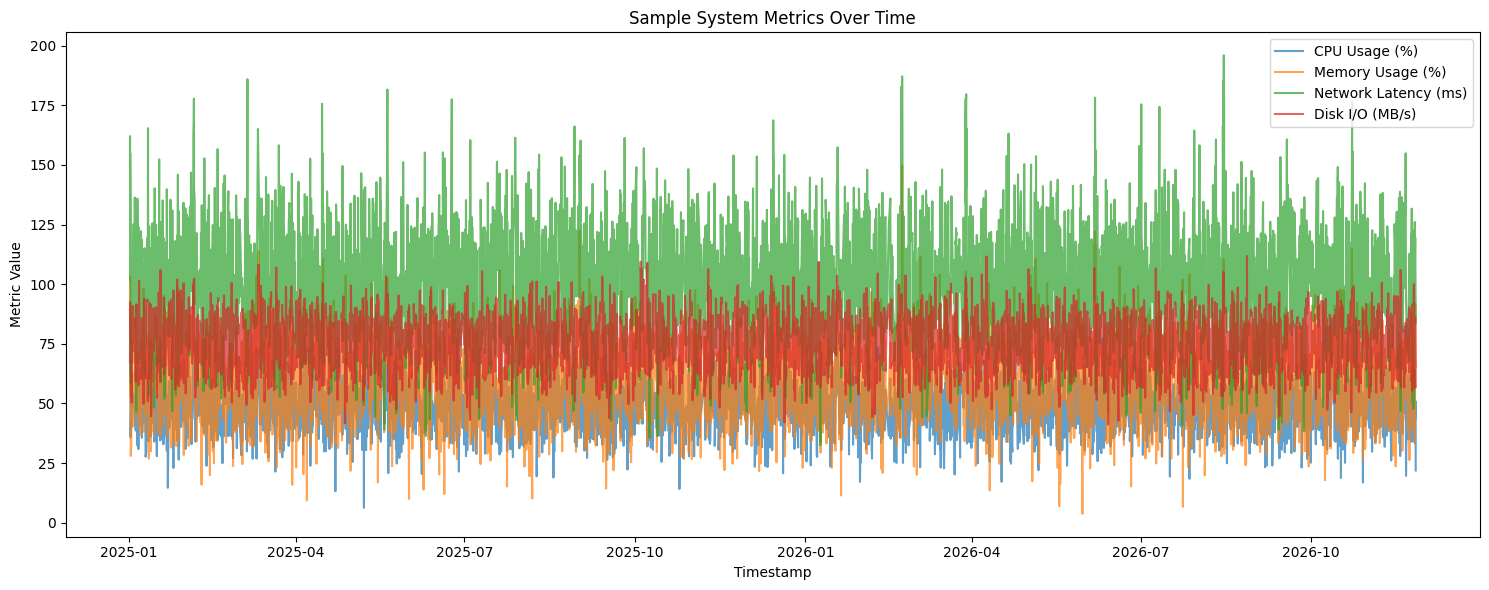

In [7]:
# 3b: Plot multiple system metrics over time
plt.figure(figsize=(15, 6))
plt.plot(sample_df['timestamp'], sample_df['cpu_usage'], label='CPU Usage (%)', alpha=0.7)
plt.plot(sample_df['timestamp'], sample_df['memory_usage'], label='Memory Usage (%)', alpha=0.7)
plt.plot(sample_df['timestamp'], sample_df['network_latency'], label='Network Latency (ms)', alpha=0.7)
plt.plot(sample_df['timestamp'], sample_df['disk_io'], label='Disk I/O (MB/s)', alpha=0.7)
plt.title('Sample System Metrics Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Metric Value')
plt.legend()
plt.tight_layout()
plt.show()



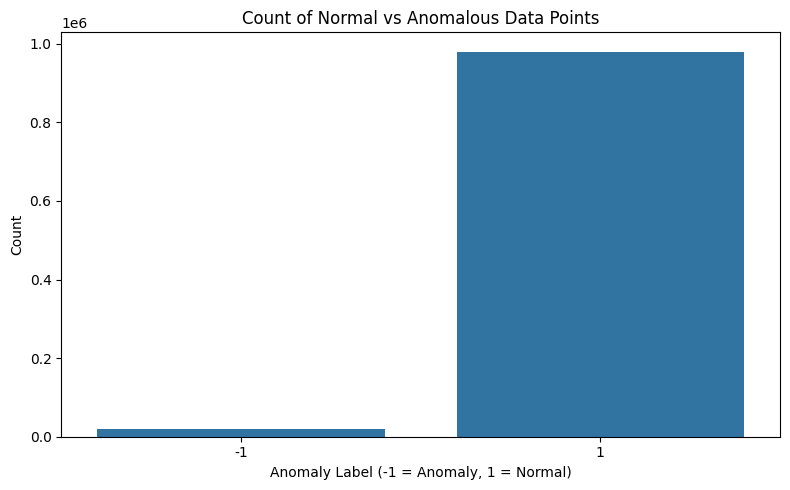

In [8]:
# 3c: Count plot of normal vs anomalous points
plt.figure(figsize=(8, 5))
sns.countplot(x='anomaly', data=df)
plt.title('Count of Normal vs Anomalous Data Points')
plt.xlabel('Anomaly Label (-1 = Anomaly, 1 = Normal)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

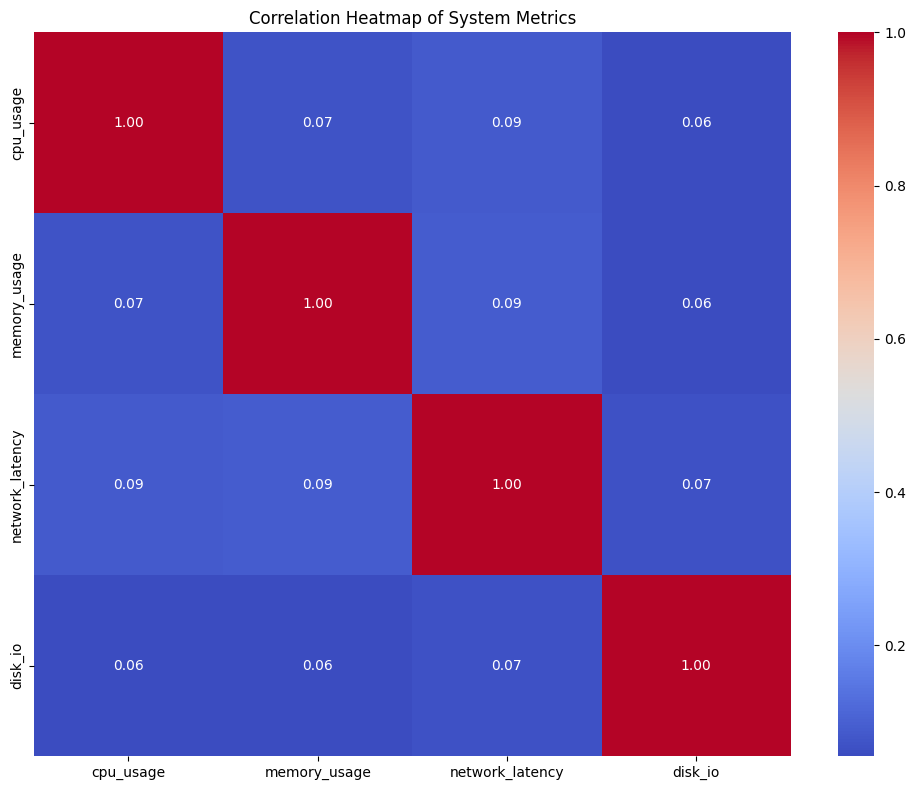

In [9]:
# 3d: Correlation heatmap of system metrics
plt.figure(figsize=(10, 8))
corr = df[['cpu_usage', 'memory_usage', 'network_latency', 'disk_io']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of System Metrics')
plt.tight_layout()
plt.show()

In [10]:
# Filter the DataFrame to show only anomalous data points
anomalous_data = df[df['anomaly'] == -1]

# Display the first few anomalous data points
print("Anomalous data points:")
display(anomalous_data.head())

# Get the number of anomalous data points
num_anomalies = anomalous_data.shape[0]
print(f"\nTotal number of anomalous data points detected: {num_anomalies}")

Anomalous data points:


,timestamp,cpu_usage,memory_usage,network_latency,disk_io,error_rate,anomaly
0,2025-01-01 00:00:00,74.967142,92.537578,171.294448,78.928398,0,-1
2,2025-01-01 00:02:00,76.476885,107.349379,152.585204,86.621920,0,-1
3,2025-01-01 00:03:00,85.230299,93.001287,120.406133,95.023779,0,-1
4,2025-01-01 00:04:00,67.658466,102.969160,143.803054,94.435034,0,-1
6,2025-01-01 00:06:00,85.792128,97.984054,143.587059,89.620535,0,-1



Total number of anomalous data points detected: 20000


In [11]:
# Select only the numeric columns for analysis, excluding 'error_rate' and 'anomaly'
numeric_cols = anomalous_data.select_dtypes(include=[float, int]).drop(columns=['error_rate', 'anomaly'])

# Calculate the mean and standard deviation for anomalous data
anomalous_mean = numeric_cols.mean()
anomalous_std = numeric_cols.std()

print("Mean of anomalous data points:")
display(anomalous_mean)

print("\nStandard deviation of anomalous data points:")
display(anomalous_std)

# Calculate the mean and standard deviation for the entire dataset (for comparison)
overall_numeric_cols = df.select_dtypes(include=[float, int]).drop(columns=['error_rate', 'anomaly'])
overall_mean = overall_numeric_cols.mean()
overall_std = overall_numeric_cols.std()

print("\nMean of overall dataset:")
display(overall_mean)

print("\nStandard deviation of overall dataset:")
display(overall_std)

# You can visually compare these statistics to get an idea of which metrics are most impacted during anomalies.
# For example, look for metrics where the mean or standard deviation of the anomalous data is significantly different from the overall data.

Mean of anomalous data points:


,0
cpu_usage,64.498229
memory_usage,82.048930
network_latency,132.106932
disk_io,84.447588



Standard deviation of anomalous data points:


,0
cpu_usage,17.728785
memory_usage,26.523001
network_latency,42.256536
disk_io,17.142324



Mean of overall dataset:


,0
cpu_usage,50.384002
memory_usage,60.596351
network_latency,101.003760
disk_io,75.306102



Standard deviation of overall dataset:


,0
cpu_usage,10.383140
memory_usage,15.598881
network_latency,21.177205
disk_io,10.208421


## Implement the Local Outlier Factor anomaly detection method and compare it with Isolation forest results

In [12]:
## The local outlier factor (lof) method
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, contamination='auto', novelty=False)

In [13]:
# The LOF model needs to be fitted to the data to calculate outlier scores.
numeric_cols = df.select_dtypes(include=[float, int]).drop(columns=['error_rate', 'anomaly'])
df['lof_anomaly_score'] = lof.fit_predict(numeric_cols)

## Evaluate and compare the results (lof vs isolation forest)

### Calculate and display the value counts for the 'anomaly' and 'lof_anomaly_score' columns and create a cross-tabulation to compare the results of the two anomaly detection methods.



In [14]:
# Get the value counts for the 'anomaly' column (Isolation Forest results)
anomaly_counts_if = df['anomaly'].value_counts()
print("Value counts for Isolation Forest anomalies (-1: Anomaly, 1: Normal):")
display(anomaly_counts_if)

# Get the value counts for the 'lof_anomaly_score' column (LOF results)
anomaly_counts_lof = df['lof_anomaly_score'].value_counts()
print("\nValue counts for LOF anomalies (-1: Anomaly, 1: Normal):")
display(anomaly_counts_lof)

# Create a cross-tabulation of the 'anomaly' and 'lof_anomaly_score' columns
cross_tab = pd.crosstab(df['anomaly'], df['lof_anomaly_score'], rownames=['Isolation Forest'], colnames=['LOF'])
print("\nCross-tabulation of Isolation Forest vs. LOF anomalies:")
display(cross_tab)

Value counts for Isolation Forest anomalies (-1: Anomaly, 1: Normal):


,count
anomaly,
1,980000
-1,20000



Value counts for LOF anomalies (-1: Anomaly, 1: Normal):


,count
lof_anomaly_score,
1,999513
-1,487



Cross-tabulation of Isolation Forest vs. LOF anomalies:


LOF,-1,1
Isolation Forest,,
-1,370,19630
1,117,979883


## Visualize the comparison

### Subtask:
Create visualizations to show how LOF identifies anomalies on the time series plots, potentially comparing them visually to the Isolation Forest results.


**Reasoning**:
Create time series plots to visualize the anomalies detected by LOF and Isolation Forest separately, and the anomalies detected by both methods on the 'cpu_usage' metric using the sampled data.



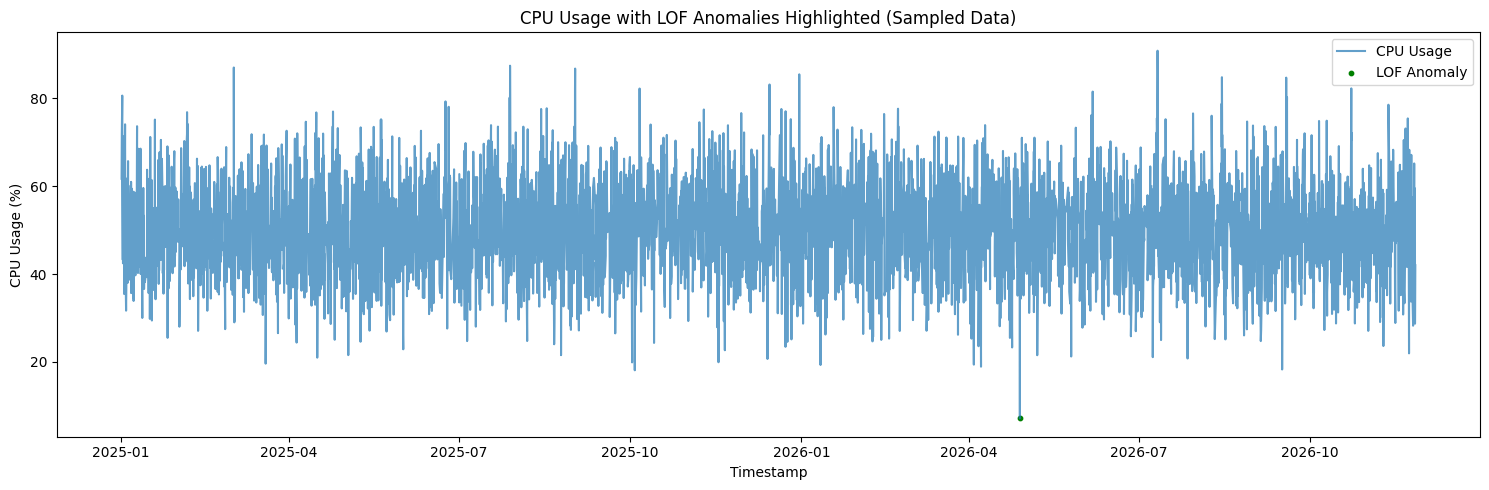

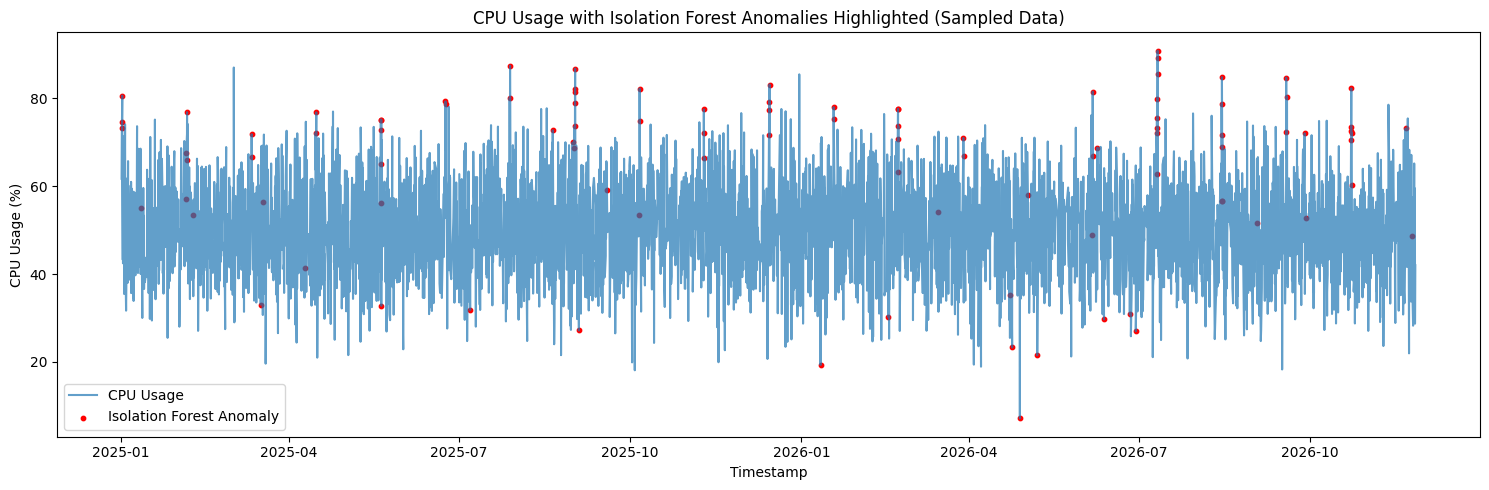

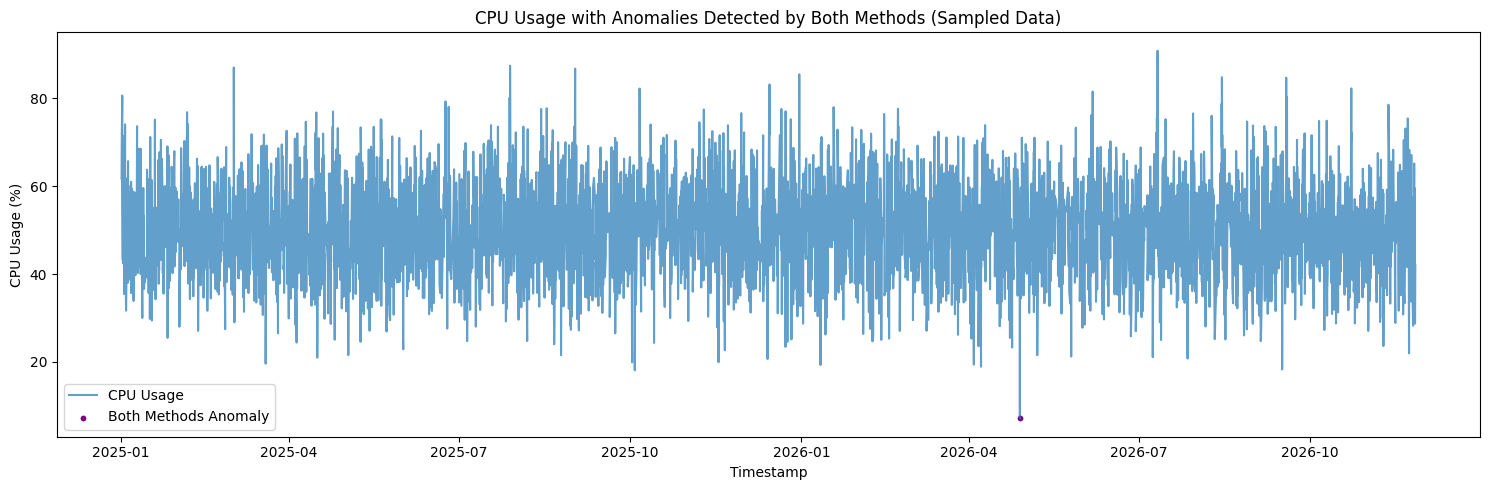

In [15]:
# Re-sample the dataframe after adding both anomaly columns
sample_df = df.sample(5000).sort_values('timestamp')

# Step 1-6: Visualize LOF anomalies on CPU usage time series
plt.figure(figsize=(15, 5))
plt.plot(sample_df['timestamp'], sample_df['cpu_usage'], label='CPU Usage', alpha=0.7)
lof_anomalies = sample_df[sample_df['lof_anomaly_score'] == -1]
plt.scatter(lof_anomalies['timestamp'], lof_anomalies['cpu_usage'], color='green', label='LOF Anomaly', s=10)
plt.title('CPU Usage with LOF Anomalies Highlighted (Sampled Data)')
plt.xlabel('Timestamp')
plt.ylabel('CPU Usage (%)')
plt.legend()
plt.tight_layout()
plt.show()

# Step 7-12: Visualize Isolation Forest anomalies on CPU usage time series
plt.figure(figsize=(15, 5))
plt.plot(sample_df['timestamp'], sample_df['cpu_usage'], label='CPU Usage', alpha=0.7)
if_anomalies = sample_df[sample_df['anomaly'] == -1]
plt.scatter(if_anomalies['timestamp'], if_anomalies['cpu_usage'],
            color='red', label='Isolation Forest Anomaly', s=10)
plt.title('CPU Usage with Isolation Forest Anomalies Highlighted (Sampled Data)')
plt.xlabel('Timestamp')
plt.ylabel('CPU Usage (%)')
plt.legend()
plt.tight_layout()
plt.show()

# Step 13-18: Visualize anomalies detected by both methods on CPU usage time series
plt.figure(figsize=(15, 5))
plt.plot(sample_df['timestamp'], sample_df['cpu_usage'], label='CPU Usage', alpha=0.7)
both_anomalies = sample_df[(sample_df['anomaly'] == -1) & (sample_df['lof_anomaly_score'] == -1)]
plt.scatter(both_anomalies['timestamp'], both_anomalies['cpu_usage'], color='purple', label='Both Methods Anomaly', s=10)
plt.title('CPU Usage with Anomalies Detected by Both Methods (Sampled Data)')
plt.xlabel('Timestamp')
plt.ylabel('CPU Usage (%)')
plt.legend()
plt.tight_layout()
plt.show()

## Summarize findings

### Subtask:
Briefly summarize the observations and differences between the LOF and Isolation Forest anomaly detection methods based on the evaluation and visualization steps.


**Reasoning**:
Summarize the findings from the evaluation and visualization steps to compare LOF and Isolation Forest.



In [16]:
print("Summary of LOF vs. Isolation Forest Anomaly Detection:")

# 1. Compare the number of anomalies detected by each method
print("\n1. Number of Anomalies Detected:")
print(f"Isolation Forest detected {anomaly_counts_if[-1]} anomalies.")
print(f"Local Outlier Factor (LOF) detected {anomaly_counts_lof[-1]} anomalies.")

# 2. Discuss the overlap and differences in detected anomalies (referencing cross-tabulation)
print("\n2. Overlap and Differences in Detected Anomalies:")
print("Cross-tabulation of Isolation Forest vs. LOF anomalies:")
display(cross_tab)
print(f"Both methods agreed on {cross_tab.loc[-1, -1]} anomalies and {cross_tab.loc[1, 1]} normal points.")
print(f"Isolation Forest detected {cross_tab.loc[-1, 1]} anomalies not detected by LOF.")
print(f"LOF detected {cross_tab.loc[1, -1]} anomalies not detected by Isolation Forest.")

# 3. Describe visual differences on time series plots
print("\n3. Visual Differences on Time Series Plots:")
print("Based on the generated plots:")
print("- Isolation Forest tends to identify more widespread anomalies, including some points that appear within normal fluctuations.")
print("- LOF appears to be more sensitive to local density variations, identifying fewer, potentially more isolated or distinct outliers.")
print("- The anomalies detected by both methods often appear in clusters or during periods of heightened activity in the metrics.")


# 4. Conclude with strengths/weaknesses in this scenario
print("\n4. Strengths and Weaknesses in this Scenario:")
print("- Isolation Forest (with default parameters/contamination) seems to be more aggressive in identifying anomalies, potentially useful for casting a wide net.")
print("- LOF identifies a smaller, potentially more 'extreme' set of outliers based on local density, which might be better for pinpointing highly unusual events.")
print("- The choice of method depends on the desired sensitivity and the nature of anomalies being sought.")

Summary of LOF vs. Isolation Forest Anomaly Detection:

1. Number of Anomalies Detected:
Isolation Forest detected 20000 anomalies.
Local Outlier Factor (LOF) detected 487 anomalies.

2. Overlap and Differences in Detected Anomalies:
Cross-tabulation of Isolation Forest vs. LOF anomalies:


LOF,-1,1
Isolation Forest,,
-1,370,19630
1,117,979883


Both methods agreed on 370 anomalies and 979883 normal points.
Isolation Forest detected 19630 anomalies not detected by LOF.
LOF detected 117 anomalies not detected by Isolation Forest.

3. Visual Differences on Time Series Plots:
Based on the generated plots:
- Isolation Forest tends to identify more widespread anomalies, including some points that appear within normal fluctuations.
- LOF appears to be more sensitive to local density variations, identifying fewer, potentially more isolated or distinct outliers.
- The anomalies detected by both methods often appear in clusters or during periods of heightened activity in the metrics.

4. Strengths and Weaknesses in this Scenario:
- Isolation Forest (with default parameters/contamination) seems to be more aggressive in identifying anomalies, potentially useful for casting a wide net.
- LOF identifies a smaller, potentially more 'extreme' set of outliers based on local density, which might be better for pinpointing highly unusual events.

## Summary:

### Data Analysis Key Findings

*   Isolation Forest detected significantly more anomalies (20,000) compared to Local Outlier Factor (LOF), which detected 487 anomalies.
*   There was a notable overlap in the anomalies detected by both methods, with 370 instances classified as anomalous by both.
*   Isolation Forest identified a large number (19,630) of anomalies that LOF did not detect.
*   LOF identified a smaller set (117) of anomalies that Isolation Forest did not detect.
*   Visualizations showed that Isolation Forest tended to identify more widespread anomalies, while LOF appeared to be more focused on identifying fewer, potentially more distinct outliers based on local density.
*   Anomalies detected by both methods often occurred in clusters or during periods of heightened activity in the metrics.

### Insights or Next Steps

*   The significant difference in the number of anomalies detected suggests that the choice of method and parameter tuning (like `contamination`) is crucial and depends on the specific goals of the anomaly detection task.
*   Further investigation into the characteristics of the anomalies uniquely identified by each method could provide insights into the types of deviations each algorithm is more sensitive to.


## 🔁 Real-Time Extension: Kafka + Spark

If you're dealing with streaming metrics in production, you can integrate this anomaly detection logic into a real-time pipeline using:

- **Apache Kafka** for streaming metric ingestion
- **Apache Spark Structured Streaming** for real-time processing
- **Isolation Forest or other models** for inference
- **Slack, Email, or Kafka topics** for alerting

Architecture:
```
System Logs → Kafka → Spark Streaming → Anomaly Model → Alerts (Slack/Email/DB)
```

Sample Kafka producer and Spark consumer code can be found in the GitHub repo accompanying this notebook.


## ✅ Next Steps

- Run this logic on real infrastructure logs
- Replace Isolation Forest with deep models like LSTM or Autoencoders
- Deploy as a microservice or integrate with real-time dashboards

If you enjoyed this notebook, feel free to connect or share it on LinkedIn or Medium.
